In [1]:
from IPython.display import clear_output
from Fetch_Live_Data import *
from Buy_Presure_Scaner import *
from Chandelier_ZLSMA import *
from Chandelier_ZLSMA_Filter import *
from EMAs_9_15_Filter import *
from Fetch_Coin_List import *
from BTC_Trend_Flower import *
from BTC_Trend import *
from Up_Trend_Scanner import *

In [2]:
df = pd.read_csv("Coin_List.csv", header=None)
coins = df[1:].iloc[:, 0].tolist()
print("Total Coins:", len(coins))

Total Coins: 291


In [25]:
# results_df = btc_trend_flower(uptrending_df['original_symbol'].tolist())
# results_df = results_df[(results_df['follows_btc'] == True) & (results_df['is_consolidation'] == False)]
# results_df

In [ ]:
btc_trend_out = only_chandelier("BTC")
if btc_trend_out.iloc[-1]['buy_signal'] == True:
    
    results_df = EMAs_9_15_Filter(
    symbols=coins,
    timeframe='15m',
    limit=200,
    max_cross_candles=3,
    max_price=100,  # Only check coins under $100
    show_details=True
)
    if len(results_df) != 0:
        uptrending_df = up_trend_scanner(results_df['symbol'].tolist(), timeframe='15m', uptrend_only=True)
        uptrending_df =  uptrending_df[ 
                                (uptrending_df['rsi'] <= 65) & 
                                (uptrending_df['criteria_macd_bullish'] == True) & 
                                (uptrending_df['criteria_higher_lows'] == True) 
                                ]

        uptrending_df = uptrending_df[['original_symbol', 'score', 'rsi', 'criteria_macd_bullish',
                            'volume_ratio', 'criteria_higher_lows']]
        
        if len(uptrending_df) != 0:
            buy_pressure = get_binance_buy_pressure(
                    uptrending_df['original_symbol'].tolist(),
                    top_n=10)

In [40]:
def crypto_trading_scanner(coins, timeframe='15m', limit=200, max_cross_candles=3, 
                        max_price=100, rsi_threshold=65, top_n=10, show_details=True, 
                        scan_interval=10, max_wait_time=None):
    """
    Comprehensive crypto trading signal scanner that checks BTC trend and filters altcoins
    
    Parameters:
    - coins: list of coin symbols to scan
    - timeframe: trading timeframe (default '15m')
    - limit: number of candles to analyze (default 200)
    - max_cross_candles: maximum candles for EMA cross (default 3)
    - max_price: maximum price filter (default 100)
    - rsi_threshold: RSI upper limit (default 65)
    - top_n: top N coins for buy pressure analysis (default 10)
    - show_details: whether to show detailed results (default True)
    - scan_interval: seconds to wait between BTC signal checks (default 10)
    - max_wait_time: maximum time to wait for BTC signal in seconds (default None = infinite)
    
    Returns:
    - buy_pressure: DataFrame with buy pressure data when BTC buy signal is active
    """
    import time
    from datetime import datetime, timedelta
    
    start_time = datetime.now()
    scan_count = 0
    
    print(f"Starting BTC signal monitor at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Scanning every {scan_interval} seconds...")
    
    while True:
        scan_count += 1
        current_time = datetime.now()
        
        # Check if max wait time exceeded
        if max_wait_time and (current_time - start_time).total_seconds() > max_wait_time:
            print(f"\nMax wait time of {max_wait_time} seconds exceeded. Stopping scanner.")
            return None
        
        # Step 1: Check BTC trend using Chandelier Exit
        try:
            btc_trend_out = only_chandelier("BTC")
            btc_buy_signal = btc_trend_out.iloc[-1]['buy_signal']
            
            print(f"[{current_time.strftime('%H:%M:%S')}] Scan #{scan_count}: BTC Buy Signal = {btc_buy_signal}")
            
            # If BTC buy signal is active, proceed with altcoin analysis
            if btc_buy_signal:
                print(f"\n🚀 BTC BUY SIGNAL DETECTED! Starting altcoin analysis...")
                break
            else:
                print(f"   Waiting {scan_interval}s for next check...")
                time.sleep(scan_interval)
                
        except Exception as e:
            print(f"   Error checking BTC signal: {e}")
            print(f"   Retrying in {scan_interval}s...")
            time.sleep(scan_interval)
    
    # Step 2: Apply EMA filter to find potential coins (with retry loop)
    while True:
        print("📊 Applying EMA filter...")
        try:
            results_df = EMAs_9_15_Filter(
                symbols=coins,
                timeframe=timeframe,
                limit=limit,
                max_cross_candles=max_cross_candles,
                max_price=max_price,
                show_details=show_details
            )
            
            if len(results_df) == 0:
                print("❌ No coins passed EMA filter. Restarting from BTC signal check...")
                print(f"   Waiting {scan_interval}s before restart...")
                time.sleep(scan_interval)
                
                # Reset and restart from BTC signal check
                scan_count = 0
                start_time = datetime.now()
                print(f"\n🔄 RESTARTING: BTC signal monitor at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
                
                # Go back to BTC signal checking loop
                while True:
                    scan_count += 1
                    current_time = datetime.now()
                    
                    # Check if max wait time exceeded
                    if max_wait_time and (current_time - start_time).total_seconds() > max_wait_time:
                        print(f"\nMax wait time of {max_wait_time} seconds exceeded. Stopping scanner.")
                        return None
                    
                    try:
                        btc_trend_out = only_chandelier("BTC")
                        btc_buy_signal = btc_trend_out.iloc[-1]['buy_signal']
                        
                        print(f"[{current_time.strftime('%H:%M:%S')}] Scan #{scan_count}: BTC Buy Signal = {btc_buy_signal}")
                        
                        if btc_buy_signal:
                            print(f"\n🚀 BTC BUY SIGNAL DETECTED! Starting altcoin analysis...")
                            break
                        else:
                            print(f"   Waiting {scan_interval}s for next check...")
                            time.sleep(scan_interval)
                            
                    except Exception as e:
                        print(f"   Error checking BTC signal: {e}")
                        print(f"   Retrying in {scan_interval}s...")
                        time.sleep(scan_interval)
                
                # Continue to next EMA filter attempt
                continue
            else:
                print(f"✅ {len(results_df)} coins passed EMA filter.")
                break
                
        except Exception as e:
            print(f"❌ Error in EMA filter: {e}")
            print(f"   Retrying in {scan_interval}s...")
            time.sleep(scan_interval)
    
    # Step 3: Scan for uptrending coins (with retry loop)
    while True:
        print("📈 Scanning for uptrending coins...")
        try:
            uptrending_df = up_trend_scanner(
                results_df['symbol'].tolist(), 
                timeframe=timeframe, 
                uptrend_only=True
            )
            
            # Step 4: Apply technical filters
            print("🔍 Applying technical analysis filters...")
            uptrending_df = uptrending_df[
                (uptrending_df['rsi'] <= rsi_threshold) & 
                (uptrending_df['criteria_macd_bullish'] == True) & 
                (uptrending_df['criteria_higher_lows'] == True)
            ]
            
            # Select relevant columns
            uptrending_df = uptrending_df[['original_symbol', 'score', 'rsi', 'criteria_macd_bullish',
                                        'volume_ratio', 'criteria_higher_lows']]
            
            if len(uptrending_df) == 0:
                print("❌ No coins passed technical analysis filters. Restarting from BTC signal check...")
                print(f"   Waiting {scan_interval}s before restart...")
                time.sleep(scan_interval)
                
                # Reset and restart from BTC signal check
                scan_count = 0
                start_time = datetime.now()
                print(f"\n🔄 RESTARTING: BTC signal monitor at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
                
                # Go back to BTC signal checking loop
                while True:
                    scan_count += 1
                    current_time = datetime.now()
                    
                    # Check if max wait time exceeded
                    if max_wait_time and (current_time - start_time).total_seconds() > max_wait_time:
                        print(f"\nMax wait time of {max_wait_time} seconds exceeded. Stopping scanner.")
                        return None
                    
                    try:
                        btc_trend_out = only_chandelier("BTC")
                        btc_buy_signal = btc_trend_out.iloc[-1]['buy_signal']
                        
                        print(f"[{current_time.strftime('%H:%M:%S')}] Scan #{scan_count}: BTC Buy Signal = {btc_buy_signal}")
                        
                        if btc_buy_signal:
                            print(f"\n🚀 BTC BUY SIGNAL DETECTED! Starting altcoin analysis...")
                            break
                        else:
                            print(f"   Waiting {scan_interval}s for next check...")
                            time.sleep(scan_interval)
                            
                    except Exception as e:
                        print(f"   Error checking BTC signal: {e}")
                        print(f"   Retrying in {scan_interval}s...")
                        time.sleep(scan_interval)
                
                # Break out of uptrending loop to restart EMA filter
                break
            else:
                print(f"✅ {len(uptrending_df)} coins passed all filters.")
                break
                
        except Exception as e:
            print(f"❌ Error in uptrend analysis: {e}")
            print(f"   Retrying in {scan_interval}s...")
            time.sleep(scan_interval)
    
    # Step 5: Get buy pressure data for top candidates (with retry loop)
    while True:
        print(f"💰 Getting buy pressure data for top {top_n} candidates...")
        try:
            buy_pressure = get_binance_buy_pressure(
                uptrending_df['original_symbol'].tolist(),
                top_n=top_n
            )
            
            if buy_pressure is None or len(buy_pressure) == 0:
                print("❌ No buy pressure data available. Restarting from BTC signal check...")
                print(f"   Waiting {scan_interval}s before restart...")
                time.sleep(scan_interval)
                
                # Reset and restart from BTC signal check
                scan_count = 0
                start_time = datetime.now()
                print(f"\n🔄 RESTARTING: BTC signal monitor at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
                
                # Go back to BTC signal checking loop
                while True:
                    scan_count += 1
                    current_time = datetime.now()
                    
                    # Check if max wait time exceeded
                    if max_wait_time and (current_time - start_time).total_seconds() > max_wait_time:
                        print(f"\nMax wait time of {max_wait_time} seconds exceeded. Stopping scanner.")
                        return None
                    
                    try:
                        btc_trend_out = only_chandelier("BTC")
                        btc_buy_signal = btc_trend_out.iloc[-1]['buy_signal']
                        
                        print(f"[{current_time.strftime('%H:%M:%S')}] Scan #{scan_count}: BTC Buy Signal = {btc_buy_signal}")
                        
                        if btc_buy_signal:
                            print(f"\n🚀 BTC BUY SIGNAL DETECTED! Starting altcoin analysis...")
                            break
                        else:
                            print(f"   Waiting {scan_interval}s for next check...")
                            time.sleep(scan_interval)
                            
                    except Exception as e:
                        print(f"   Error checking BTC signal: {e}")
                        print(f"   Retrying in {scan_interval}s...")
                        time.sleep(scan_interval)
                
                # Break out of buy pressure loop to restart entire process
                break
            else:
                # Success! We have buy pressure data
                total_time = datetime.now() - start_time
                print(f"\n🎯 Analysis completed in {total_time.total_seconds():.1f} seconds!")
                print(f"📋 Final results: {len(buy_pressure)} coins with buy pressure data")
                return buy_pressure
                
        except Exception as e:
            print(f"❌ Error getting buy pressure data: {e}")
            print(f"   Retrying in {scan_interval}s...")
            time.sleep(scan_interval)

In [ ]:
# Usage examples:
# 
# # Run indefinitely until BTC buy signal
# result = crypto_trading_scanner(coins)
# 
# # Run with 5-minute timeout
# result = crypto_trading_scanner(coins, max_wait_time=300)
# 
# # Custom scan interval (every 5 seconds)
# result = crypto_trading_scanner(coins, scan_interval=5)

In [41]:
result = crypto_trading_scanner(coins, scan_interval=5)

Starting BTC signal monitor at 2025-07-01 11:35:59
Scanning every 5 seconds...
Fetching BTC/USDT data from Binance...
[11:35:59] Scan #1: BTC Buy Signal = 1

🚀 BTC BUY SIGNAL DETECTED! Starting altcoin analysis...
📊 Applying EMA filter...
Loading Binance markets...
Analyzing 291 symbols...
✓ XECUSDT: Valid signal found! (Cross 2 candles ago)
✓ IQUSDT: Valid signal found! (Cross 0 candles ago)
✓ VETUSDT: Valid signal found! (Cross 0 candles ago)
✓ HBARUSDT: Valid signal found! (Cross 2 candles ago)
✓ SEIUSDT: Valid signal found! (Cross 1 candles ago)
✓ FDUSDUSDT: Valid signal found! (Cross 2 candles ago)
✓ SANTOSUSDT: Valid signal found! (Cross 1 candles ago)
✓ DCRUSDT: Valid signal found! (Cross 2 candles ago)

Found 8 symbols with valid EMA cross signals:

Symbol: IQUSDT
  Current Price: $0.00344300
  EMA9: $0.00342873 | EMA15: $0.00342756
  Candles Since Cross: 0
  Cross Price: $0.00344300
  Price Change Since Cross: 0.00000000%
  EMA Difference: 0.03399291%
  Cross Time: 2025-07-01 

In [42]:
result

,rank,symbol,current_buy_pressure,current_sell_pressure,avg_buy_pressure_5periods,buy_pressure_trend,latest_price_change,latest_volume,volume_trend,volatility,timestamp,signal,momentum
0,1,IQUSDT,43.17,56.83,51.97,-2.31,0.44,1.342895e+07,60.22,1.86,2025-07-01T11:38:35.091786,AVOID,STRONG
1,2,DCRUSDT,42.01,57.99,51.68,-2.54,0.60,6.515940e+02,6.98,1.04,2025-07-01T11:38:35.088345,AVOID,GOOD
2,3,HBARUSDT,46.11,53.89,48.87,1.36,0.38,2.385722e+06,10.09,0.88,2025-07-01T11:38:35.084503,AVOID,STRONG


In [43]:
from Trade_Execution import *
#bot.trade('BTCUSDT', 100, 3.0)
bot.trade('HBARUSDT', 20, use_fixed_tp=True, fixed_tp_percent=2.0)

2025-07-01 11:41:31,764 - INFO - 
2025-07-01 11:41:31,765 - INFO - 🚀 INITIATING TRADE: HBARUSDT with $20
2025-07-01 11:41:31,766 - INFO - ============================================================
2025-07-01 11:41:31,766 - INFO - 📊 Processing HBAR/USDT...
2025-07-01 11:41:31,767 - INFO - 💰 Checking balance...
2025-07-01 11:41:31,871 - INFO - ✅ Balance sufficient: $20.76
2025-07-01 11:41:31,872 - INFO - 📈 Fetching market data...
2025-07-01 11:41:31,918 - INFO - 📊 Current price: $0.15103000
2025-07-01 11:41:31,976 - INFO - 📊 ATR value: $0.00075990
2025-07-01 11:41:31,978 - INFO - 🔢 Calculating position size...
2025-07-01 11:41:31,980 - INFO - 📊 Position size: 132.00000000 HBAR
2025-07-01 11:41:31,981 - INFO - 📊 Calculated levels:
2025-07-01 11:41:31,983 - INFO -    Stop Loss: $0.14989014
2025-07-01 11:41:31,985 - INFO -    Take Profit (Fixed 2.0%): $0.15405060
2025-07-01 11:41:31,986 - INFO - 🔥 EXECUTING BUY ORDER...
2025-07-01 11:41:32,037 - INFO - ⚡ Order executed in 0.05 seconds
202

True

In [44]:
import pandas as pd
import ccxt
from datetime import datetime

def display_live_trade_status(csv_file_path, exchange_name='binance'):
    """
    Display current trade situation from CSV data with live price updates
    
    Args:
        csv_file_path (str): Path to the CSV file
        exchange_name (str): Exchange name for live price fetching
    """
    try:
        # Initialize exchange
        exchange = getattr(ccxt, exchange_name)({
            'sandbox': False,
            'rateLimit': 1200,
            'enableRateLimit': True,
        })
        
        # Read CSV and get last ENTRY trade
        df = pd.read_csv(csv_file_path)
        entry_trades = df[df['Action'] == 'ENTRY']
        
        if entry_trades.empty:
            print("❌ No ENTRY trades found in the data")
            return
        
        # Get the last entry trade
        trade = entry_trades.iloc[-1]
        
        # Extract trade data
        symbol = trade['Symbol']
        entry_price = float(trade['Entry_Price'])
        amount = float(trade['Amount'])
        invested_usd = float(trade['Invested_USD'])
        stop_loss = float(trade['Stop_Loss']) if pd.notna(trade['Stop_Loss']) else None
        take_profit = float(trade['Take_Profit']) if pd.notna(trade['Take_Profit']) else None
        
        # Get current price
        try:
            ticker = exchange.fetch_ticker(symbol)
            current_price = ticker['last']
            price_change_24h = ticker['percentage']
        except Exception as e:
            print(f"⚠️ Could not fetch live price: {e}")
            current_price = None
            price_change_24h = None
        
        # Calculate current situation
        if current_price:
            current_value = amount * current_price
            pnl_usd = current_value - invested_usd
            pnl_percent = (pnl_usd / invested_usd) * 100
            price_change_from_entry = ((current_price - entry_price) / entry_price) * 100
            
            # Determine trade status
            if stop_loss and current_price <= stop_loss:
                status = "🔴 STOP LOSS HIT"
                status_color = "RED"
            elif take_profit and current_price >= take_profit:
                status = "🟢 TAKE PROFIT HIT"
                status_color = "GREEN"
            elif pnl_percent > 0:
                status = "🟢 IN PROFIT"
                status_color = "GREEN"
            else:
                status = "🔴 IN LOSS"
                status_color = "RED"
        else:
            status = "⚪ PRICE DATA UNAVAILABLE"
            status_color = "GRAY"
        
        # Display trade situation
        print("\n" + "="*60)
        print(f"📊 LIVE TRADE STATUS - {trade['Coin'].upper()}")
        print("="*60)
        
        print(f"\n📍 TRADE INFO:")
        print(f"   Symbol: {symbol}")
        print(f"   Entry Date: {trade['Date']} {trade['Time']}")
        print(f"   Entry Price: ${entry_price:.8f}")
        print(f"   Amount: {amount:.2f} {trade['Coin']}")
        print(f"   Invested: ${invested_usd:.2f}")
        
        if current_price:
            print(f"\n💰 CURRENT SITUATION:")
            print(f"   Current Price: ${current_price:.8f}")
            print(f"   Current Value: ${current_value:.2f}")
            print(f"   P&L: ${pnl_usd:+.2f} ({pnl_percent:+.2f}%)")
            print(f"   Price Change from Entry: {price_change_from_entry:+.2f}%")
            if price_change_24h:
                print(f"   24h Market Change: {price_change_24h:+.2f}%")
        
        print(f"\n🎯 TARGETS:")
        if stop_loss:
            sl_distance = ((current_price - stop_loss) / stop_loss * 100) if current_price else 0
            print(f"   Stop Loss: ${stop_loss:.8f} ({sl_distance:+.2f}% away)")
        else:
            print(f"   Stop Loss: Not Set")
            
        if take_profit:
            tp_distance = ((take_profit - current_price) / current_price * 100) if current_price else 0
            print(f"   Take Profit: ${take_profit:.8f} ({tp_distance:+.2f}% away)")
        else:
            print(f"   Take Profit: Not Set")
        
        print(f"\n🚨 STATUS: {status}")
        
        # Risk assessment
        if current_price and stop_loss:
            risk_amount = (entry_price - stop_loss) * amount
            risk_percent = (risk_amount / invested_usd) * 100
            print(f"\n⚠️  RISK ANALYSIS:")
            print(f"   Max Risk: ${risk_amount:.2f} ({risk_percent:.2f}%)")
            
            if take_profit:
                reward_amount = (take_profit - entry_price) * amount
                risk_reward = reward_amount / risk_amount if risk_amount > 0 else 0
                print(f"   Potential Reward: ${reward_amount:.2f}")
                print(f"   Risk:Reward Ratio: 1:{risk_reward:.2f}")
        
        print(f"\n⏰ Last Updated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print("="*60)
        
        # Quick summary
        if current_price:
            if pnl_percent > 5:
                print("✅ Trade performing well!")
            elif pnl_percent > 0:
                print("📈 Trade in small profit")
            elif pnl_percent > -5:
                print("📉 Trade in small loss")
            else:
                print("⚠️ Trade in significant loss")
        
    except Exception as e:
        print(f"❌ Error: {str(e)}")

# Example usage:
# display_live_trade_status('your_trades.csv')

# For multiple updates, you can create a monitoring function:
def monitor_trade(csv_file_path, update_interval=30):
    """
    Continuously monitor trade status
    
    Args:
        csv_file_path (str): Path to CSV file
        update_interval (int): Update interval in seconds
    """
    import time
    
    print("🔄 Starting trade monitoring...")
    print(f"📊 Updates every {update_interval} seconds")
    print("Press Ctrl+C to stop\n")
    
    try:
        while True:
            display_live_trade_status(csv_file_path)
            print(f"\n⏳ Next update in {update_interval} seconds...")
            time.sleep(update_interval)
    except KeyboardInterrupt:
        print("\n👋 Monitoring stopped.")

# Usage examples:
# monitor_trade('your_trades.csv', 60)  # Update every minute

In [82]:
import pandas as pd
import ccxt
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

def display_live_trade_with_graph(csv_file_path, exchange_name='binance', show_graph=True):
    """
    Display current trade situation with visual graph
    
    Args:
        csv_file_path (str): Path to the CSV file
        exchange_name (str): Exchange name for live price fetching
        show_graph (bool): Whether to display the graph
    """
    try:
        # Initialize exchange
        exchange = getattr(ccxt, exchange_name)({
            'sandbox': False,
            'rateLimit': 1200,
            'enableRateLimit': True,
        })
        
        # Read CSV and get last ENTRY trade
        df = pd.read_csv(csv_file_path)
        entry_trades = df[df['Action'] == 'ENTRY']
        
        if entry_trades.empty:
            print("❌ No ENTRY trades found in the data")
            return
        
        # Get the last entry trade
        trade = entry_trades.iloc[-1]
        
        # Extract trade data
        symbol = trade['Symbol']
        entry_price = float(trade['Entry_Price'])
        amount = float(trade['Amount'])
        invested_usd = float(trade['Invested_USD'])
        stop_loss = float(trade['Stop_Loss']) if pd.notna(trade['Stop_Loss']) else None
        take_profit = float(trade['Take_Profit']) if pd.notna(trade['Take_Profit']) else None
        entry_date = trade['Date']
        entry_time = trade['Time']
        
        # Get current price and historical data
        try:
            ticker = exchange.fetch_ticker(symbol)
            current_price = ticker['last']
            price_change_24h = ticker['percentage']
            
            # Fetch historical data for graph (last 24-48 hours)
            ohlcv = exchange.fetch_ohlcv(symbol, '1h', limit=48)
            historical_data = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
            historical_data['datetime'] = pd.to_datetime(historical_data['timestamp'], unit='ms')
            
            # Fetch BTC data for comparison
            btc_ohlcv = exchange.fetch_ohlcv('BTC/USDT', '1h', limit=48)
            btc_data = pd.DataFrame(btc_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
            btc_data['datetime'] = pd.to_datetime(btc_data['timestamp'], unit='ms')
            btc_ticker = exchange.fetch_ticker('BTC/USDT')
            btc_price_change_24h = btc_ticker['percentage']
            
        except Exception as e:
            print(f"⚠️ Could not fetch live data: {e}")
            current_price = None
            price_change_24h = None
            historical_data = None
            btc_data = None
            btc_price_change_24h = None
        
        # Calculate current situation
        if current_price:
            current_value = amount * current_price
            pnl_usd = current_value - invested_usd
            pnl_percent = (pnl_usd / invested_usd) * 100
            price_change_from_entry = ((current_price - entry_price) / entry_price) * 100
            
            # Determine trade status
            if stop_loss and current_price <= stop_loss:
                status = "🔴 STOP LOSS HIT"
                status_color = "red"
            elif take_profit and current_price >= take_profit:
                status = "🟢 TAKE PROFIT HIT"
                status_color = "green"
            elif pnl_percent > 0:
                status = "🟢 IN PROFIT"
                status_color = "green"
            else:
                status = "🔴 IN LOSS"
                status_color = "red"
        else:
            status = "⚪ PRICE DATA UNAVAILABLE"
            status_color = "gray"
        
        # Display trade situation (text)
        print("\n" + "="*60)
        print(f"📊 LIVE TRADE STATUS - {trade['Coin'].upper()}")
        print("="*60)
        
        print(f"\n📍 TRADE INFO:")
        print(f"   Symbol: {symbol}")
        print(f"   Entry Date: {entry_date} {entry_time}")
        print(f"   Entry Price: ${entry_price:.8f}")
        print(f"   Amount: {amount:.2f} {trade['Coin']}")
        print(f"   Invested: ${invested_usd:.2f}")
        
        if current_price:
            print(f"\n💰 CURRENT SITUATION:")
            print(f"   Current Price: ${current_price:.8f}")
            print(f"   Current Value: ${current_value:.2f}")
            print(f"   P&L: ${pnl_usd:+.2f} ({pnl_percent:+.2f}%)")
            print(f"   Price Change from Entry: {price_change_from_entry:+.2f}%")
            if price_change_24h:
                print(f"   24h Market Change: {price_change_24h:+.2f}%")
            if btc_price_change_24h:
                print(f"   BTC 24h Change: {btc_price_change_24h:+.2f}%")
        
        print(f"\n🎯 TARGETS:")
        if stop_loss:
            sl_distance = ((current_price - stop_loss) / stop_loss * 100) if current_price else 0
            print(f"   Stop Loss: ${stop_loss:.8f} ({sl_distance:+.2f}% away)")
        else:
            print(f"   Stop Loss: Not Set")
            
        if take_profit:
            tp_distance = ((take_profit - current_price) / current_price * 100) if current_price else 0
            print(f"   Take Profit: ${take_profit:.8f} ({tp_distance:+.2f}% away)")
        else:
            print(f"   Take Profit: Not Set")
        
        print(f"\n🚨 STATUS: {status}")
        
        # Create the graph
        if show_graph and historical_data is not None and current_price:
            create_trade_graph(historical_data, btc_data, entry_price, current_price, stop_loss, 
                             take_profit, symbol, status_color, entry_date, entry_time)
        
        print(f"\n⏰ Last Updated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print("="*60)
        
    except Exception as e:
        print(f"❌ Error: {str(e)}")

def create_trade_graph(historical_data, btc_data, entry_price, current_price, stop_loss, 
                      take_profit, symbol, status_color, entry_date, entry_time):
    """
    Create a visual graph showing trade position with BTC comparison
    """
    try:
        # Create figure with subplots
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), 
                                      gridspec_kw={'height_ratios': [1, 1]})
        fig.suptitle(f'{symbol} - Live Trade Position with BTC Correlation', fontsize=16, fontweight='bold')
        
        # Your coin price chart (top subplot)
        ax1.plot(historical_data['datetime'], historical_data['close'], 
                color='#2E86AB', linewidth=2.5, label=f'{symbol} Price')
        
        # Add horizontal lines for key levels
        ax1.axhline(y=entry_price, color='blue', linestyle='--', linewidth=2, 
                   label=f'Entry: ${entry_price:.6f}', alpha=0.8)
        
        if stop_loss:
            ax1.axhline(y=stop_loss, color='red', linestyle='--', linewidth=2, 
                       label=f'Stop Loss: ${stop_loss:.6f}', alpha=0.8)
        
        if take_profit:
            ax1.axhline(y=take_profit, color='green', linestyle='--', linewidth=2, 
                       label=f'Take Profit: ${take_profit:.6f}', alpha=0.8)
        
        # Highlight current price
        ax1.scatter([historical_data['datetime'].iloc[-1]], [current_price], 
                   color=status_color, s=120, zorder=5, 
                   label=f'Current: ${current_price:.6f}')
        
        # Fill areas between entry and targets
        if stop_loss:
            ax1.fill_between(historical_data['datetime'], stop_loss, entry_price, 
                           alpha=0.2, color='red')
        
        if take_profit:
            ax1.fill_between(historical_data['datetime'], entry_price, take_profit, 
                           alpha=0.2, color='green')
        
        # Formatting price chart
        ax1.set_ylabel(f'{symbol} Price (USDT)', fontsize=12, fontweight='bold')
        ax1.set_title(f'{symbol} Price Movement with Trade Levels', fontsize=14)
        ax1.legend(loc='upper left', bbox_to_anchor=(0.01, 0.99), fontsize=9, framealpha=0.9)
        ax1.grid(True, alpha=0.3)
        ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.6f}'))
        
        # BTC price chart (bottom subplot)
        if btc_data is not None:
            ax2.plot(btc_data['datetime'], btc_data['close'], 
                    color='#F7931A', linewidth=2.5, label='BTC Price')
            
            # Highlight current BTC price
            ax2.scatter([btc_data['datetime'].iloc[-1]], [btc_data['close'].iloc[-1]], 
                       color='orange', s=120, zorder=5, 
                       label=f'Current BTC: ${btc_data["close"].iloc[-1]:,.0f}')
            
            ax2.set_ylabel('BTC Price (USDT)', fontsize=12, fontweight='bold')
            ax2.set_xlabel('Time', fontsize=12)
            ax2.set_title('Bitcoin Price Movement (Market Context)', fontsize=14)
            ax2.legend(loc='upper right', bbox_to_anchor=(0.99, 0.99), fontsize=9, framealpha=0.9)
            ax2.grid(True, alpha=0.3)
            ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
            
            # Format x-axis
            ax2.tick_params(axis='x', rotation=45)
        
        # Add correlation analysis
        correlation_text = create_correlation_analysis(historical_data, btc_data, symbol)
        
        # Add trade statistics text box
        stats_text = create_stats_text_with_btc(entry_price, current_price, stop_loss, 
                                               take_profit, btc_data, correlation_text)
        ax1.text(0.02, 0.02, stats_text, transform=ax1.transAxes, fontsize=9,
                verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"⚠️ Error creating graph: {e}")

def create_correlation_analysis(coin_data, btc_data, symbol):
    """Analyze correlation between your coin and BTC"""
    try:
        if btc_data is None or len(coin_data) != len(btc_data):
            return "Correlation: N/A"
        
        # Calculate percentage changes
        coin_pct_change = coin_data['close'].pct_change().dropna()
        btc_pct_change = btc_data['close'].pct_change().dropna()
        
        # Ensure same length
        min_length = min(len(coin_pct_change), len(btc_pct_change))
        coin_pct_change = coin_pct_change.iloc[-min_length:]
        btc_pct_change = btc_pct_change.iloc[-min_length:]
        
        # Calculate correlation
        correlation = np.corrcoef(coin_pct_change, btc_pct_change)[0, 1]
        
        if correlation > 0.7:
            corr_status = "Strong Positive"
        elif correlation > 0.3:
            corr_status = "Moderate Positive"
        elif correlation > -0.3:
            corr_status = "Weak/No Correlation"
        elif correlation > -0.7:
            corr_status = "Moderate Negative"
        else:
            corr_status = "Strong Negative"
        
        return f"BTC Correlation: {correlation:.2f} ({corr_status})"
        
    except Exception as e:
        return f"Correlation: Error ({str(e)[:20]})"

def create_stats_text_with_btc(entry_price, current_price, stop_loss, take_profit, btc_data, correlation_text):
    """Create statistics text including BTC analysis"""
    price_change = ((current_price - entry_price) / entry_price) * 100
    
    stats = f"📊 Trade Stats:\n"
    stats += f"Price Change: {price_change:+.2f}%\n"
    
    if stop_loss:
        sl_distance = ((current_price - stop_loss) / stop_loss) * 100
        stats += f"SL Distance: {sl_distance:+.2f}%\n"
    
    if take_profit:
        tp_distance = ((take_profit - current_price) / current_price) * 100
        stats += f"TP Distance: {tp_distance:+.2f}%\n"
    
    if stop_loss and take_profit:
        risk = entry_price - stop_loss
        reward = take_profit - entry_price
        rr_ratio = reward / risk if risk > 0 else 0
        stats += f"R:R Ratio: 1:{rr_ratio:.2f}\n"
    
    # Add BTC analysis
    if btc_data is not None:
        btc_change = ((btc_data['close'].iloc[-1] - btc_data['close'].iloc[0]) / btc_data['close'].iloc[0]) * 100
        stats += f"\n₿ BTC Analysis:\n"
        stats += f"BTC Change: {btc_change:+.2f}%\n"
        stats += f"{correlation_text}"
    
    return stats

def monitor_trade_with_graph(csv_file_path, update_interval=300):
    """
    Continuously monitor trade with periodic graph updates
    
    Args:
        csv_file_path (str): Path to CSV file
        update_interval (int): Update interval in seconds (default 5 minutes)
    """
    import time
    
    print("🔄 Starting trade monitoring with graphs...")
    print(f"📊 Updates every {update_interval//60} minutes")
    print("Press Ctrl+C to stop\n")
    
    try:
        while True:
            display_live_trade_with_graph(csv_file_path)
            print(f"\n⏳ Next update in {update_interval//60} minutes...")
            time.sleep(update_interval)
    except KeyboardInterrupt:
        print("\n👋 Monitoring stopped.")

# Usage examples:
# display_live_trade_with_graph('your_trades.csv')
# monitor_trade_with_graph('your_trades.csv', 300)  # Update every 5 minutes

🔄 Starting trade monitoring with graphs...
📊 Updates every 0 minutes
Press Ctrl+C to stop


📊 LIVE TRADE STATUS - HBAR

📍 TRADE INFO:
   Symbol: HBAR/USDT
   Entry Date: 2025-07-01 11:41:32
   Entry Price: $0.15104720
   Amount: 132.00 HBAR
   Invested: $20.00

💰 CURRENT SITUATION:
   Current Price: $0.15128000
   Current Value: $19.97
   P&L: $-0.03 (-0.16%)
   Price Change from Entry: +0.15%
   24h Market Change: -0.05%
   BTC 24h Change: -1.16%

🎯 TARGETS:
   Stop Loss: $0.14989014 (+0.93% away)
   Take Profit: $0.15405060 (+1.83% away)

🚨 STATUS: 🔴 IN LOSS


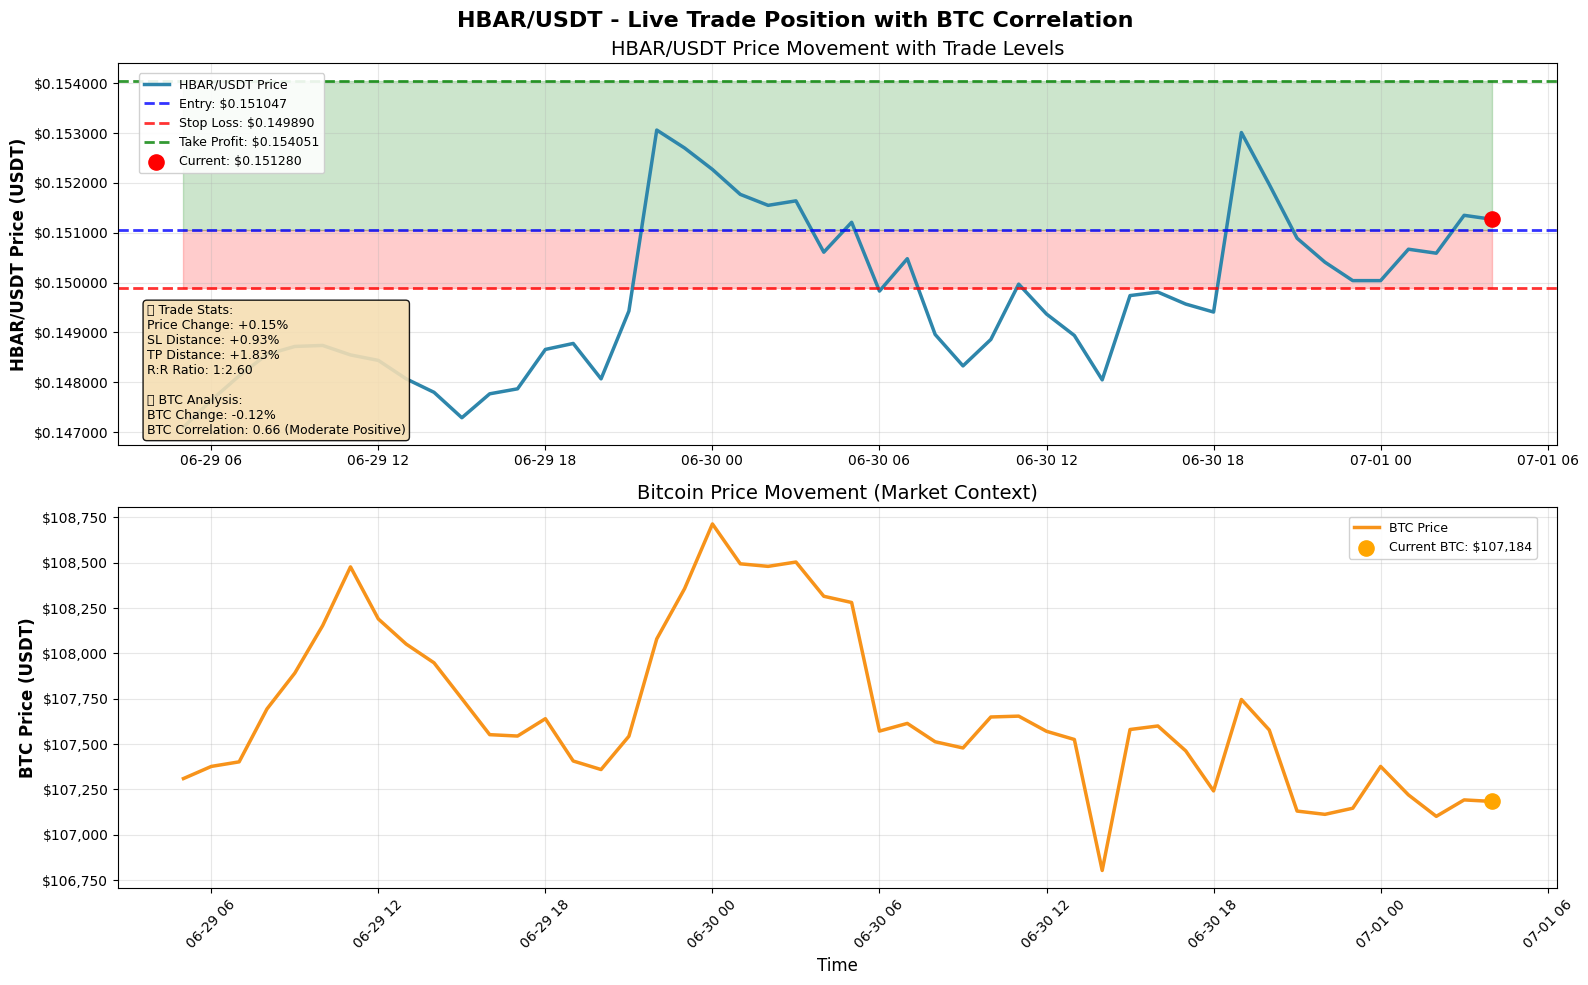


⏰ Last Updated: 2025-07-01 13:21:23

⏳ Next update in 0 minutes...


In [ ]:
monitor_trade_with_graph("/home/lisa/Arupreza/LiveBot/home/lisa/Arupreza/LiveBot/trading_report_2025-07-01.csv", 10)